In [1]:
import pandas as pd

# Load data
df = pd.read_csv("mobile_price.csv")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Target (ground truth)
y = df["price_range"]

# Features (ALL columns except target)
X = df.drop(columns=["price_range"])

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def map_clusters_to_labels(y_true, y_cluster):
    y_true = np.array(y_true)
    y_cluster = np.array(y_cluster)

    labels_true = np.unique(y_true)
    labels_cluster = np.unique(y_cluster)

    cost_matrix = np.zeros((len(labels_cluster), len(labels_true)))

    for i, c in enumerate(labels_cluster):
        for j, t in enumerate(labels_true):
            cost_matrix[i, j] = -np.sum((y_cluster == c) & (y_true == t))

    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    mapping = {labels_cluster[r]: labels_true[c] for r, c in zip(row_ind, col_ind)}

    y_pred = np.array([mapping[c] for c in y_cluster])
    return y_pred

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro"),
        "recall": recall_score(y_true, y_pred, average="macro"),
        "f1": f1_score(y_true, y_pred, average="macro"),
    }

In [6]:
from sklearn.cluster import KMeans

# Number of clusters = number of classes
n_clusters = y.nunique()

seed = 42  # test one seed first

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=seed,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Map cluster IDs → actual labels
y_pred = map_clusters_to_labels(y, clusters)

# Evaluate
scores = evaluate(y, y_pred)

print("Single seed result:")
print(scores)

Single seed result:
{'accuracy': 0.297, 'precision': 0.29662298991082614, 'recall': 0.297, 'f1': 0.29503453092077575}


In [7]:
seeds = [0, 10, 42, 100, 999]

results = []

for seed in seeds:
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=seed,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled)
    y_pred = map_clusters_to_labels(y, clusters)
    scores = evaluate(y, y_pred)

    results.append({
        "seed": seed,
        **scores
    })

results_df = pd.DataFrame(results)

print("\nResults for each seed:")
print(results_df)


Results for each seed:
   seed  accuracy  precision  recall        f1
0     0    0.2945   0.294042  0.2945  0.292637
1    10    0.2955   0.295336  0.2955  0.293648
2    42    0.2970   0.296623  0.2970  0.295035
3   100    0.2955   0.294995  0.2955  0.293510
4   999    0.2985   0.298367  0.2985  0.295579


### Enhancing K-means Clustering with Association Rule Mining

In [8]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [9]:
selected_features = ["ram", "int_memory", "px_width", "battery_power"]

X_rule_source = df[selected_features].copy()

In [10]:
def categorize_343(series):
    min_val = series.min()
    max_val = series.max()
    value_range = max_val - min_val

    low_threshold = min_val + value_range * 0.3
    high_threshold = min_val + value_range * 0.7

    def assign_category(x):
        if x <= low_threshold:
            return "low"
        elif x <= high_threshold:
            return "medium"
        else:
            return "high"

    return series.apply(assign_category)


categorized_df = pd.DataFrame()

for col in selected_features:
    categorized_df[col] = categorize_343(X_rule_source[col])

print(categorized_df.head())

      ram int_memory px_width battery_power
0  medium        low      low           low
1  medium       high     high        medium
2  medium     medium     high           low
3  medium        low     high           low
4  medium     medium   medium          high


In [11]:
transaction_items = pd.DataFrame(index=categorized_df.index)

for col in selected_features:
    for level in ["low", "medium", "high"]:
        item_name = f"{col}_{level}"
        transaction_items[item_name] = (categorized_df[col] == level)

print(transaction_items.head())
print(transaction_items.shape)

   ram_low  ram_medium  ram_high  int_memory_low  int_memory_medium  \
0    False        True     False            True              False   
1    False        True     False           False              False   
2    False        True     False           False               True   
3    False        True     False            True              False   
4    False        True     False           False               True   

   int_memory_high  px_width_low  px_width_medium  px_width_high  \
0            False          True            False          False   
1             True         False            False           True   
2            False         False            False           True   
3            False         False            False           True   
4            False         False             True          False   

   battery_power_low  battery_power_medium  battery_power_high  
0               True                 False               False  
1              False              

In [12]:
frequent_patterns = fpgrowth(
    transaction_items,
    min_support=0.3,
    use_colnames=True
)

frequent_patterns = frequent_patterns.sort_values(
    by="support",
    ascending=False
)

print("Frequent patterns:")
print(frequent_patterns)

Frequent patterns:
   support                           itemsets
5   0.4055       frozenset({px_width_medium})
0   0.4050            frozenset({ram_medium})
4   0.3915     frozenset({int_memory_medium})
3   0.3835  frozenset({battery_power_medium})
1   0.3255        frozenset({int_memory_low})
2   0.3160     frozenset({battery_power_low})
7   0.3020               frozenset({ram_low})
6   0.3005    frozenset({battery_power_high})


In [13]:
rules = association_rules(
    frequent_patterns,
    metric="confidence",
    min_threshold=0.4
)

rules = rules[
    (rules["support"] >= 0.3) &
    (rules["confidence"] >= 0.4) &
    (rules["lift"] >= 0.8)
].copy()

rules = rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
)

print("Association rules:")
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]])

Association rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [14]:
def create_pattern_features(transaction_items, frequent_patterns):
    pattern_features = pd.DataFrame(index=transaction_items.index)

    for i, itemset in enumerate(frequent_patterns["itemsets"]):
        items = list(itemset)

        pattern_features[f"fp_pattern_{i}"] = (
            transaction_items[items].all(axis=1).astype(int)
        )

    return pattern_features


pattern_features = create_pattern_features(
    transaction_items,
    frequent_patterns
)

print("Pattern feature shape:", pattern_features.shape)
print(pattern_features.head())

Pattern feature shape: (2000, 8)
   fp_pattern_0  fp_pattern_1  fp_pattern_2  fp_pattern_3  fp_pattern_4  \
0             0             1             0             0             1   
1             0             1             0             1             0   
2             0             1             1             0             0   
3             0             1             0             0             1   
4             1             1             1             0             0   

   fp_pattern_5  fp_pattern_6  fp_pattern_7  
0             1             0             0  
1             0             0             0  
2             1             0             0  
3             1             0             0  
4             0             0             1  


In [15]:
pattern_scaler = StandardScaler()
pattern_features_scaled = pattern_scaler.fit_transform(pattern_features)

# 可以調整，代表 FP-growth pattern 的重要程度
pattern_weight = 1.5
pattern_features_scaled = pattern_features_scaled * pattern_weight

X_fp_kmeans = np.hstack([
    X_scaled,
    pattern_features_scaled
])

print("Original feature shape:", X_scaled.shape)
print("FP-growth enhanced feature shape:", X_fp_kmeans.shape)

Original feature shape: (2000, 20)
FP-growth enhanced feature shape: (2000, 28)


In [16]:
fp_kmeans_results = []

for seed in seeds:
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=seed,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_fp_kmeans)

    y_pred = map_clusters_to_labels(y, clusters)

    scores = evaluate(y, y_pred)

    fp_kmeans_results.append({
        "seed": seed,
        "method": "FP-growth K-means",
        **scores
    })

fp_kmeans_df = pd.DataFrame(fp_kmeans_results)

print(fp_kmeans_df)

   seed             method  accuracy  precision  recall        f1
0     0  FP-growth K-means    0.3630   0.427274  0.3630  0.375350
1    10  FP-growth K-means    0.3630   0.427274  0.3630  0.375350
2    42  FP-growth K-means    0.4495   0.469815  0.4495  0.457241
3   100  FP-growth K-means    0.3630   0.427274  0.3630  0.375350
4   999  FP-growth K-means    0.3630   0.427274  0.3630  0.375350


In [17]:
original_df = results_df.copy()
original_df["method"] = "Original K-means"

comparison_df = pd.concat(
    [original_df, fp_kmeans_df],
    ignore_index=True
)

average_comparison = comparison_df.groupby("method")[
    ["accuracy", "precision", "recall", "f1"]
].mean()

print("Average comparison:")
print(average_comparison)

Average comparison:
                   accuracy  precision  recall        f1
method                                                  
FP-growth K-means    0.3803   0.435782  0.3803  0.391728
Original K-means     0.2962   0.295873  0.2962  0.294082


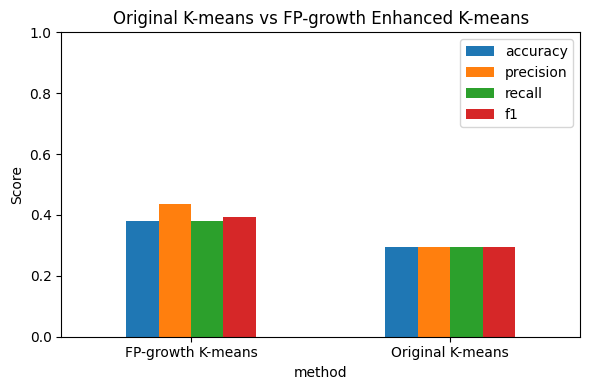

In [18]:
import matplotlib.pyplot as plt

average_comparison.plot(kind="bar", figsize=(6, 4))

plt.title("Original K-means vs FP-growth Enhanced K-means")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()